
---

# **Bagging Classifier**

---

In [22]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    classification_report,
)
from sklearn.tree import (
    plot_tree,
    DecisionTreeClassifier,
)
from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

In [6]:
# load iris data
df = sns.load_dataset("iris")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
# label encoder to encode the categprical columns
encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

In [8]:
# The filter condition excludes rows where the 'species' column is equal to 0
# We then select only the 'sepal_length', 'sepal_width', and 'species' columns
df = df[df['species'] != 0][['sepal_length', 'sepal_width', 'species']]

In [9]:
df.head()

,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


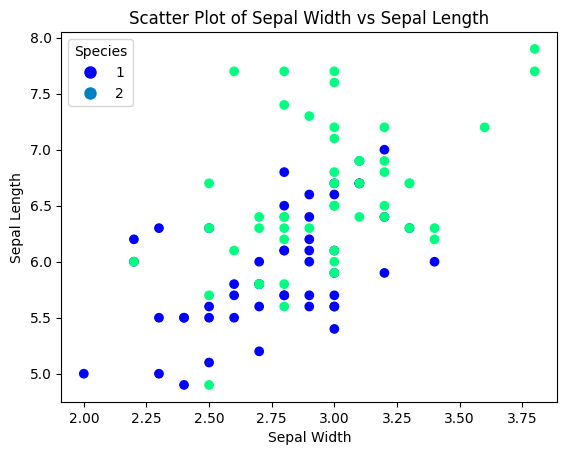

In [11]:
# Create scatter plot
plt.scatter(df['sepal_width'], df['sepal_length'], c=df['species'], cmap='winter')

# Add labels and title
plt.xlabel('Sepal Width')
plt.ylabel('Sepal Length')
plt.title('Scatter Plot of Sepal Width vs Sepal Length')

# Create legend
# Assuming species is a categorical variable, you can get unique species for the legend
species_unique = df['species'].unique()
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.winter(i / len(species_unique)), markersize=10) for i in range(len(species_unique))]
plt.legend(handles, species_unique, title='Species')

# Show plot
plt.show()

In [12]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [13]:
df_train

,sepal_length,sepal_width,species
106,4.9,2.5,2
69,5.6,2.5,1
81,5.5,2.4,1
63,6.1,2.9,1
131,7.9,3.8,2
128,6.4,2.8,2
88,5.6,3.0,1
96,5.7,2.9,1
105,7.6,3.0,2
68,6.2,2.2,1


In [14]:
df_val

,sepal_length,sepal_width,species
67,5.8,2.7,1
144,6.7,3.3,2
146,6.3,2.5,2
82,5.8,2.7,1
126,6.2,2.8,2


In [15]:
df_test

,sepal_length,sepal_width,species
83,6.0,2.7,1
89,5.5,2.5,1
139,6.9,3.1,2
122,7.7,2.8,2
75,6.6,3.0,1


In [16]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [17]:
y_test

array([1, 2, 2, 1, 2])

### **Case 1 - Bagging**

In [18]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_length,sepal_width,species
131,7.9,3.8,2
106,4.9,2.5,2
88,5.6,3.0,1
128,6.4,2.8,2
88,5.6,3.0,1
81,5.5,2.4,1
128,6.4,2.8,2
69,5.6,2.5,1


In [21]:
dt_bag1 = DecisionTreeClassifier()

In [25]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")

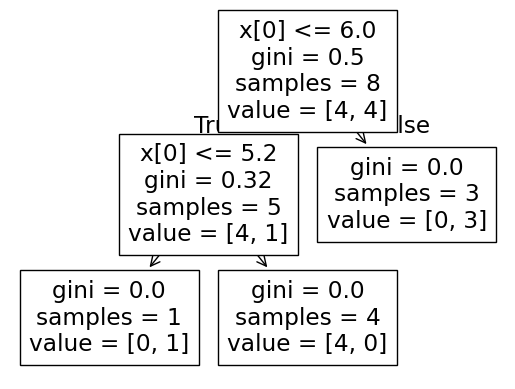

Accuracy Score: 1.0


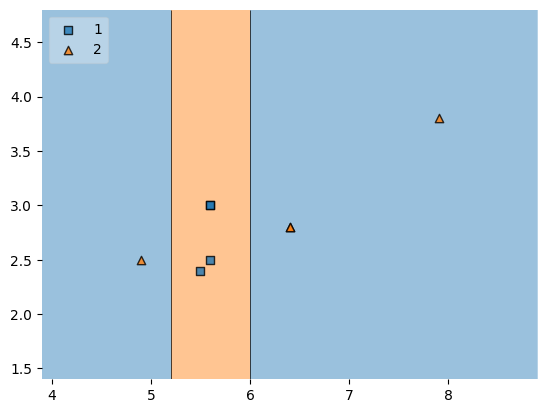

In [26]:
evaluate(dt_bag1,X,y)

In [27]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_length,sepal_width,species
96,5.7,2.9,1
131,7.9,3.8,2
106,4.9,2.5,2
105,7.6,3.0,2
63,6.1,2.9,1
63,6.1,2.9,1
106,4.9,2.5,2
63,6.1,2.9,1


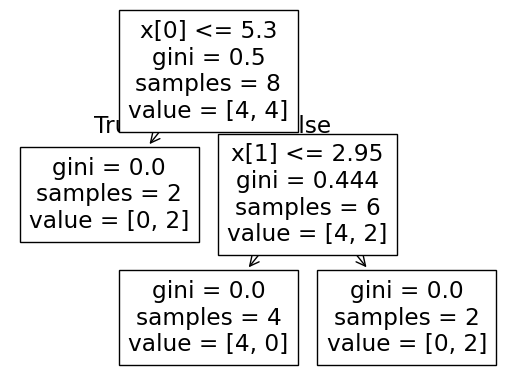

Accuracy Score: 0.6


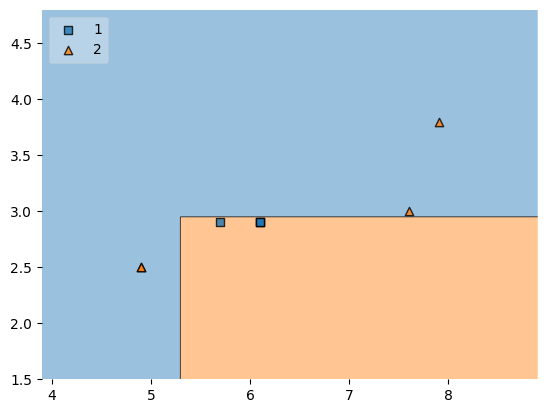

In [28]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_length,sepal_width,species
96,5.7,2.9,1
63,6.1,2.9,1
63,6.1,2.9,1
128,6.4,2.8,2
96,5.7,2.9,1
96,5.7,2.9,1
81,5.5,2.4,1
105,7.6,3.0,2


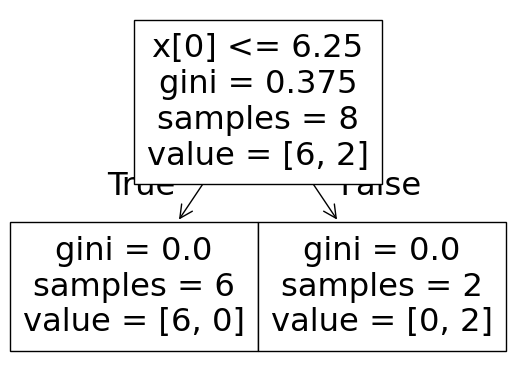

Accuracy Score: 0.8


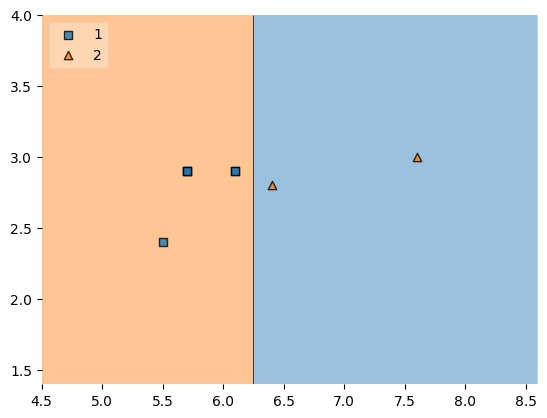

In [30]:

dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

### **Prediction / Aggregation**

In [31]:
df_test

,sepal_length,sepal_width,species
83,6.0,2.7,1
89,5.5,2.5,1
139,6.9,3.1,2
122,7.7,2.8,2
75,6.6,3.0,1


In [32]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [1]


---